In [12]:
import cv2
import torch
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

#-----------------------------------------------------------
# Ultralytics YOLO API
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
model_yolo = YOLO("yolo11s.pt").to(device)

type(image_input) <class 'numpy.ndarray'>

0: 640x448 10 persons, 17.0ms
Speed: 27.8ms preprocess, 17.0ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 448)


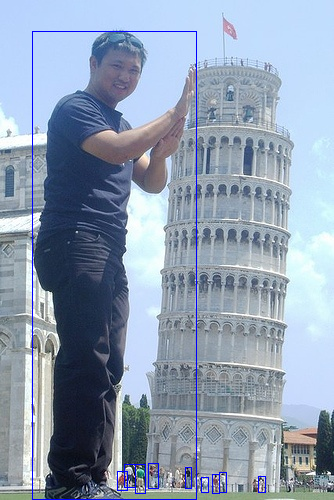

In [13]:
image_path = "./test_images/pisa_person.jpg"
# print('image_path', image_path)
image_input = cv2.imread(image_path) # np array = (500, 334, 3)
print('type(image_input)', type(image_input))
# Convert BGR (OpenCV default) to RGB
img_rgb = cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB) # np array = (500, 334, 3)
predict_YOLO = model_yolo(img_rgb)
bboxes_person = []
for pred in predict_YOLO:
    boxes = pred.boxes.xyxy.cpu().numpy()
    classes = pred.boxes.cls.cpu().numpy()
    for box, cls in zip(boxes, classes):
      if pred.names[int(cls)] == "person":
        x1, y1, x2, y2 = map(int, box[:4])
        bboxes_person.append((x1, y1, x2, y2))
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 0, 255), 1)
# Convert array to PIL image and display
display(Image.fromarray(img_rgb))

In [14]:
#--------------------------------------------------------------
# Inference : Distance from Depth Estimation : Hugging Face API
# 
from transformers import DepthProImageProcessorFast, DepthProForDepthEstimation
checkpoint = "apple/DepthPro-hf"
image_processor = DepthProImageProcessorFast.from_pretrained(checkpoint, dtype=torch.float16)
model = DepthProForDepthEstimation.from_pretrained(checkpoint, dtype=torch.float16).to(device)
model.eval()   
             
image =  Image.open(image_path)  # PIL.JpegImagePlugin.JpegImageFile 
inputs = image_processor(images=image, return_tensors="pt").to(device)
print('type(inputs) :', type(inputs)) # transformers.image_processing_base.BatchFeature
with torch.no_grad():
    outputs = model(**inputs)

type(inputs) : <class 'transformers.image_processing_base.BatchFeature'>


In [15]:
# Interpolate to resize to original size
post_processed_output = image_processor.post_process_depth_estimation(outputs, target_sizes=[(image.height, image.width)])
print('type(post_processed_output) :', type(post_processed_output)) # List
print('len(post_processed_output) :', len(post_processed_output))  #  1
print('type(post_processed_output[0]) :', type(post_processed_output[0])) #dict
print('Keys :', post_processed_output[0].keys())

# FOV & focal length predictions
field_of_view = post_processed_output[0]["field_of_view"]
focal_length = post_processed_output[0]["focal_length"]
# Metric Depth Map prediction (distance for a pixel)
predicted_depth = post_processed_output[0]["predicted_depth"]
depth_np = predicted_depth.squeeze().cpu().numpy()  # tensor to numpy
print('fov :', field_of_view)
print('focal length :', focal_length)
print('Metric Depth (meter) \n:', depth_np)

type(post_processed_output) : <class 'list'>
len(post_processed_output) : 1
type(post_processed_output[0]) : <class 'dict'>
Keys : dict_keys(['predicted_depth', 'field_of_view', 'focal_length'])
fov : tensor(24.7500, device='cuda:0', dtype=torch.float16)
focal length : tensor(761.5000, device='cuda:0', dtype=torch.float16)
Metric Depth (meter) 
: [[      10000       10000       10000 ...       10000       10000       10000]
 [      10000       10000       10000 ...       10000       10000       10000]
 [      10000       10000       10000 ...       10000       10000       10000]
 ...
 [     19.484      19.109      19.328 ...      25.188      24.562      24.688]
 [     19.172      18.891      19.234 ...      24.359      23.969      22.625]
 [     19.641      18.719      19.047 ...      23.359        23.5      21.516]]


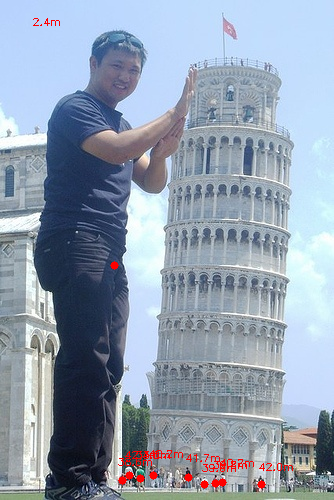

In [5]:
image_input = cv2.imread(image_path)
for x1, y1, x2, y2 in bboxes_person:
  center_x = (x1 + x2)//2
  center_y = (y1 + y2)//2

  depth_value = depth_np[center_y, center_x]
  # text = str(round(depth_value,2)) +"m"
  text = f"{depth_value:.1f}m"
  font = cv2.FONT_HERSHEY_SIMPLEX
  font_scale = 0.35 # 글자 크기 축소
  font_thickness = 1
  text_x = x1
  text_y = y1 - 6

  # 배경 박스 제거 → 텍스트만 Red로 출력
  cv2.putText(image_input, text, (text_x, text_y), font, font_scale, (0, 0, 255), font_thickness)  # BGR: Red = (0,0,255)
  # center point: Red 표시
  cv2.circle(image_input, (center_x, center_y), 4, (0, 0, 255), -1)  # radius=4, filled
# Convert BGR (OpenCV default) to RGB
img_rgb = cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB)
display(Image.fromarray(img_rgb))


Converting Metric Depth to Color Map
- 추론된 이미지의 depth_np (metric depth) 특성:
  - 범위: 2.18m ~ 10000m
  - 하늘, 먼 배경 등 depth 추정 불가 영역 → 10000 ( sentinel vals /클리핑 최대값 )으로 처리
  - linear_norm = (depth - 2.18) / (10000 - 2.18) => 관심 영역(2~25m)은 0~0.0025 범위에 몰림
    => colormap에서 색상 차이가 거의 없어 시각적으로 구분 불가

In [6]:
depth_max = depth_np.max()
depth_min = depth_np.min()
print(f"Predicted depth range: {depth_min:.2f}...{depth_max:.2f} (meters)")

inverse_depth = 1.0 / (depth_np + 1e-6)   # zero division 방지
# Step 2: Min-Max Normalization → [0.0, 1.0]
d_min = inverse_depth.min()
d_max = inverse_depth.max()
inverse_depth_normalized = (inverse_depth - d_min) / (d_max - d_min + 1e-6)
print('inverse_depth_normalized :', inverse_depth_normalized)



Predicted depth range: 2.18...10000.00 (meters)
inverse_depth_normalized : [[          0           0           0 ...           0           0           0]
 [          0           0           0 ...           0           0           0]
 [          0           0           0 ...           0           0           0]
 ...
 [    0.11188     0.11407     0.11273 ...    0.086487    0.088684    0.088196]
 [    0.11365     0.11542     0.11334 ...    0.089417    0.090881    0.096252]
 [    0.11096     0.11646     0.11438 ...    0.093262    0.092712     0.10126]]


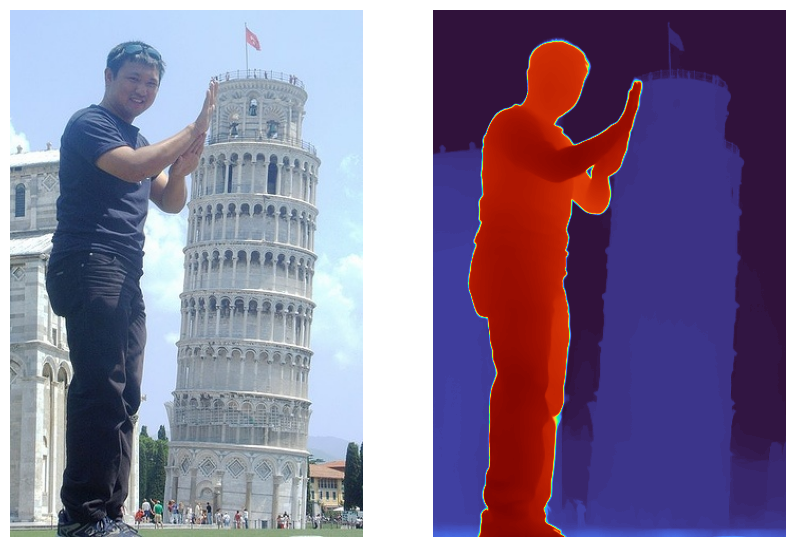

In [7]:
# The depth map is visualized as a color map.
import matplotlib.pyplot as plt
import matplotlib.image as img

def ConvertDepthToColor(image, depth):
    fig = plt.figure(figsize=(10, 7)) 
    fig.add_subplot(1, 2, 1)
    plt.imshow(image)
    plt.axis('off')
    fig.add_subplot(1, 2, 2)
    #================ Normalization Method For ColorMap ======================
    # Step 1: Inverse depth (가까울수록 큰 값 → 직관적 시각화)
    #         sentinel 10000 → 1/10000 ≈ 0 으로 자연스럽게 처리됨
    inverse_depth = 1.0 / (depth + 1e-6)   # zero division 방지
    # Step 2: Min-Max Normalization → [0.0, 1.0]
    d_min = inverse_depth.min()
    d_max = inverse_depth.max()
    inverse_depth_normalized = (inverse_depth - d_min) / (d_max - d_min + 1e-6)
    plt.imshow(inverse_depth_normalized, cmap ='turbo')  # e.g. cmap='plasma'
    #=========================================================================
    # (depth - 2.18) / (10000 - 2.18) : 관심 영역(2~25m)은 0~0.0025 범위에 몰림
    # colormap에서 색상 차이가 거의 없어 시각적으로 구분 불가
    # depth_normalized = (depth - depth.min()) / (depth.max() - depth.min())
    # plt.imshow(depth_normalized, cmap ='turbo')  
    plt.axis('off')
    plt.show()
    
image = img.imread(image_path)
ConvertDepthToColor(image, depth_np)

In [16]:
import open3d as o3d
import numpy as np

image_path = "./test_images/pisa_person.jpg"
image_input = cv2.imread(image_path) # array = (500, 334, 3)
img_rgb = cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB) 
# sentinel 10000 제거 (유효 depth만 사용)
depth_clean = depth_np.copy()
depth_clean[depth_clean > 50.0] = 0.0  # 0으로 마스킹 → open3d에서 invalid로 처리
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color=o3d.geometry.Image(np.array(img_rgb)),
    depth=o3d.geometry.Image(depth_clean.astype(np.float32)),  # ✅ float32
    depth_scale=1.0,         # depth 단위가 미터이므로 1.0
    depth_trunc=50.0,        # 50m 초과 제거
    convert_rgb_to_intensity=False
)

width, height = img_rgb.shape[0], img_rgb.shape[1]
focal_np = focal_length.squeeze().cpu().numpy()
print(f"focal_length raw: {focal_np:.4f}")  # 단위 확인용

# DepthPro는 픽셀 단위 focal length 반환
intrinsic = o3d.camera.PinholeCameraIntrinsic(
    width=width,
    height=height,
    fx=float(focal_np),
    fy=float(focal_np),
    cx=width / 2.0,
    cy=height/ 2.0
)
"""
    intrinsics (matrix) for a pinhole camera model
    fov is given in degrees and central principal point
    f  = 0.5 * W / np.tan(0.5 * fov * np.pi/180.0)
    cx = 0.5 * W 
    cy = 0.5 * H
    intrinsics = np.array([[f, 0, cx],
                           [0, f, cy],
                           [0, 0,  1]])
"""
# o3d.geometry.PointCloud.create_from_rgbd_image(image, intrinsic, 
#                                                extrinsic=(with default value))
# extrinsic (numpy.ndarray[float64[4, 4]], optional) 
# – array([[1., 0., 0., 0.], 
#          [0., 1., 0., 0.], 
#          [0., 0., 1., 0.], 
#          [0., 0., 0., 1.]])

pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_image, intrinsic)
"""
    Given depth value d at (u, v) image coordinate, 
    the corresponding 3d point is:
        z = d [u, v] / depth_scale
        x = (u - cx) * z / fx
        y = (v - cy) * z / fy
"""
# 카메라 좌표계 → 일반적인 시각화 좌표계로 flip 
pcd.transform([[1, 0, 0, 0],    
               [0, -1, 0, 0],
               [0, 0, -1, 0],
               [0, 0, 0, 1]])

"""  pcd = [x,y,z,1]
pcd * tranform matrix = [1, 0, 0, 0 ][ x ] 
                        [0, -1, 0, 0][ y ]    
                        [0, 0, -1, 0][ z ]  
                        [0, 0, 0, 1 ][ 1 ]  
"""

points = np.asarray(pcd.points)
colors = np.asarray(pcd.colors)
print(f"Total points: {len(points)}")
print(f"X range: {points[:,0].min():.2f} ~ {points[:,0].max():.2f}")
print(f"Y range: {points[:,1].min():.2f} ~ {points[:,1].max():.2f}")
print(f"Z range: {points[:,2].min():.2f} ~ {points[:,2].max():.2f}")

o3d.io.write_point_cloud("pisa_person.ply", pcd)
o3d.visualization.draw_geometries([pcd])

focal_length raw: 761.5000
Total points: 103879
X range: -16.26 ~ 5.43
Y range: -20.98 ~ 8.59
Z range: -49.94 ~ -2.18


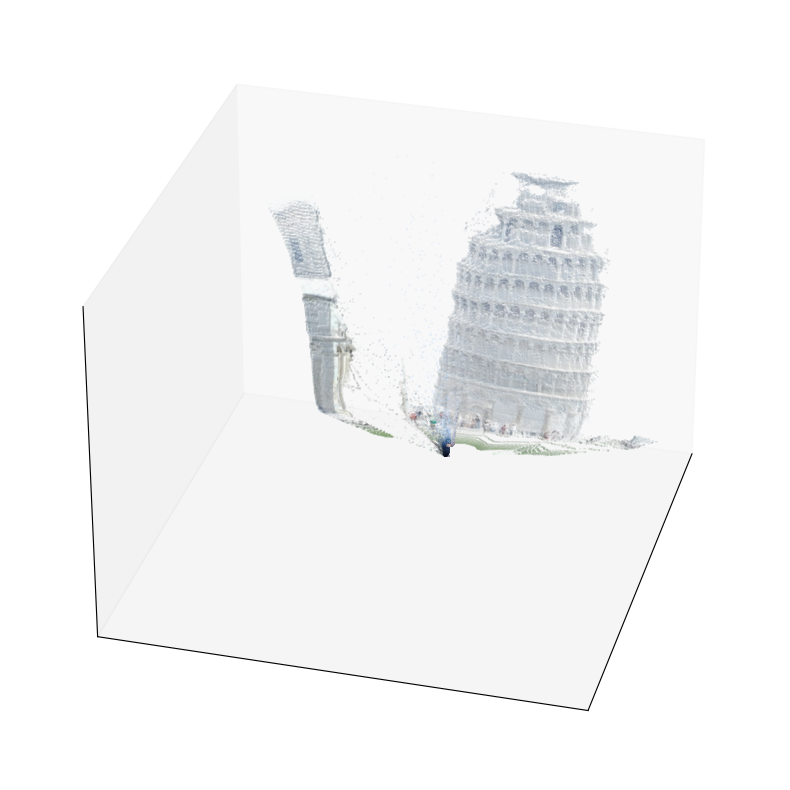

In [17]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 2], points[:, 0], points[:, 1], c=colors, s=0.1, marker='.')

ax.view_init(elev=30, azim=15) # Change this to adjust the viewpoint
# scale = 0.2 # 0.2배로 확대
# ax.set_xlim(-5*scale, 5*scale)
# ax.set_ylim(-5*scale, 5*scale)
# ax.set_zlim(-5*scale, 5*scale)
ax.set_xticks([])  
ax.set_yticks([])  
ax.set_zticks([]) 
ax.grid(True)

plt.tight_layout()
plt.show()

In [18]:
import plotly.graph_objects as go

# colors는 [0,1] float → plotly는 'rgb(r,g,b)' 문자열 필요
colors_255 = (colors * 255).astype(np.uint8)
marker_colors = [f'rgb({r},{g},{b})' for r, g, b in colors_255]

fig = go.Figure(data=[go.Scatter3d(
    x=-points[:, 0],   # X (좌우반전)
    y=points[:, 2],   # Z (깊이, 앞뒤)
    z=points[:, 1],   # Y (상하)
    mode='markers',
    marker=dict( size=1.0, color=marker_colors, opacity=1.0 )
)])

fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='black',
        camera=dict(eye=dict(x=0, y=-2, z=0.5))  # 초기 시점
    ),
    paper_bgcolor='black',
    margin=dict(l=0, r=0, t=0, b=0)
)

fig.show()
